In [2]:
import matplotlib.pyplot as plt
import geopandas
from cartopy import crs as ccrs
from geodatasets import get_path

path = get_path("naturalearth.land")
df = geopandas.read_file(path)

<Axes: >

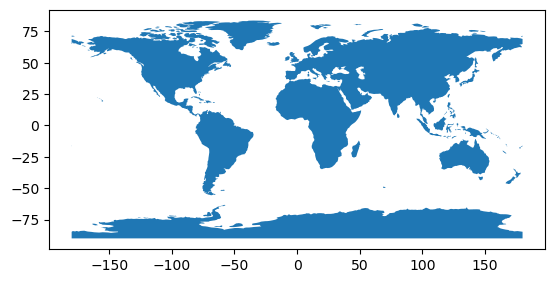

In [3]:
df.plot()

<Axes: >

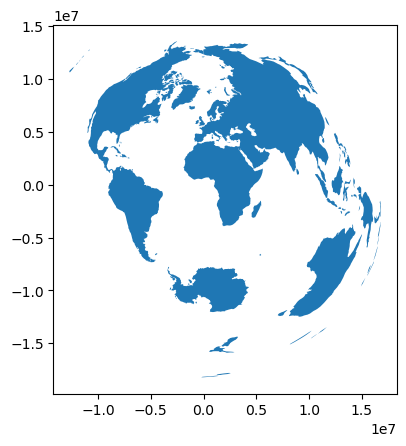

In [4]:
crs = ccrs.AzimuthalEquidistant()

crs_proj4 = crs.proj4_init
df_ae = df.to_crs(crs_proj4)

df_ae.plot()

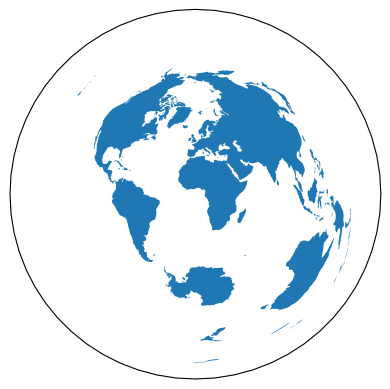

In [5]:
fig, ax = plt.subplots(subplot_kw={"projection": crs})
ax.add_geometries(df_ae["geometry"], crs=crs)

<GeoAxes: >

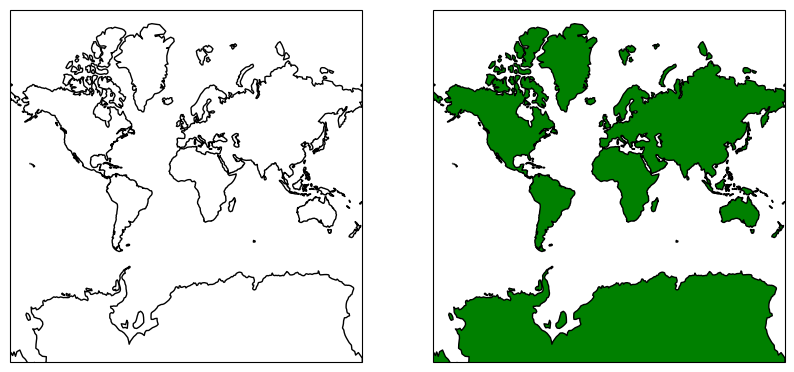

In [6]:
crs_epsg = ccrs.epsg("3857")
df_epsg = df.to_crs(epsg="3857")

fig, axs = plt.subplots(1, 2, subplot_kw={"projection": crs_epsg}, figsize=(10,5))

axs[0].add_geometries(
    df_epsg["geometry"], crs=crs_epsg, facecolor="white", edgecolor="black"
)

df_epsg.plot(ax=axs[1], color="green", edgecolor="black")

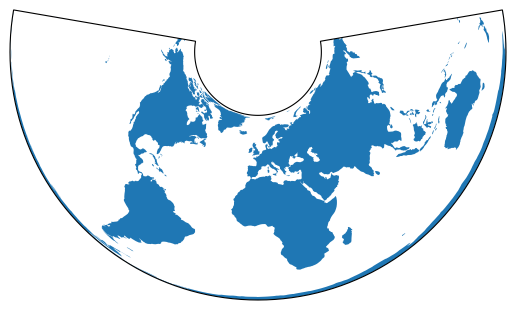

In [7]:
crs_new = ccrs.AlbersEqualArea()
new_geometries = [
    crs_new.project_geometry(ii, src_crs=crs) for ii in df_ae["geometry"].values
]

fig, ax = plt.subplots(subplot_kw={"projection": crs_new})
ax.add_geometries(new_geometries, crs=crs_new)

<Axes: >

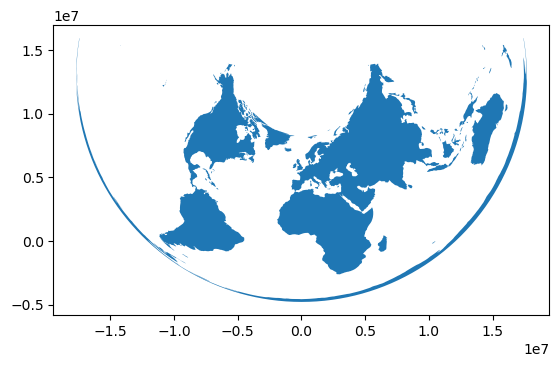

In [8]:
df_aea = geopandas.GeoDataFrame(
    df.drop(columns="geometry"), geometry=new_geometries, crs=crs_new.proj4_init
)
df_aea.plot()

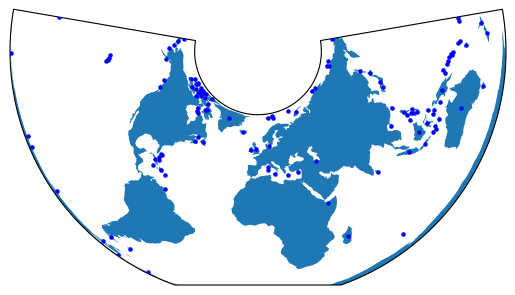

In [9]:
fig, ax = plt.subplots(subplot_kw={"projection":crs_new})
ax.add_geometries(new_geometries, crs=crs_new)

df_aea_centroids = df_aea.geometry.centroid

df_aea_centroids.plot(ax=ax, markersize=5, color="b", zorder=10)

plt.show()

<Axes: >

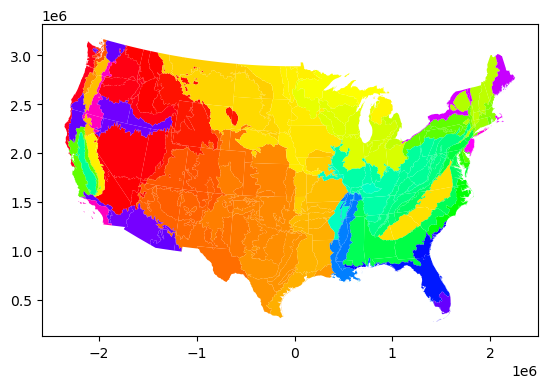

In [29]:
# part 2

df = geopandas.read_file("C:/Users/thewe/OneDrive/Desktop/College/AES408/files/us_eco_l3_state_boundaries/us_eco_l3_state_boundaries.shp")
df.plot(cmap='gist_rainbow')